In [1]:
import pandas as pd
import numpy as np
import os
from glob import glob
import seaborn as sns
import matplotlib.pyplot as plt
from autopath.analysis_smd import SteeredMDAnalysis
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from scipy.ndimage import gaussian_filter1d


Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************

Please install openmmtools to use Girsanov reweighting.
/home/manu/micromamba/envs/autopath/lib/python3.12/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.A

In [2]:
# from scipy.constants import R  # noqa: WPS347
# from scipy.integrate import cumulative_trapezoid
# RT = R * self.temperature / 1e3

In [3]:
smd_folder = 'sMD'
sysname = '3ptb'
logs = glob(f"{sysname}/{smd_folder}/sMD_*_*_forward.dat")#[:10]
trajs = glob(f"{sysname}/{smd_folder}/sMD_*_*_forward.dcd")
smd = SteeredMDAnalysis(logs, 
                        sysname, 
                        # bin_width=None,#0.02,                
                        # dist_minmax=(0.0, 1.8), #nm                        
                        # cluster_paths='traces',
                        trajectories=trajs,
                        reference_pdb=f"../equilibration/{sysname}/equilibration/{sysname}_equilibrated.pdb",
                        # pocket_select="protein and resid 218 219 262 263 305 306 49 50 91 92 133 134 175 176 and name CA", # my own selection
                        pocket_select="protein and resid 189 192 195 214 215 219 and name CA", # my own selection
                        ligand_select='resname UNK and not name H*',
                        timestep=0.004)
results, gmm_results = smd.run_analysis()
smd.raw_data.to_csv(f"{sysname}/{smd_folder}/sMD_data_raw.csv")
results.head()

,step,r_coord,speed,path,Wmean,Wdiss,dG,dG_Jarzynski,dG_Jarzynski_gmm,Wmean_gmm,Wdiss_gmm,dG_gmm,Wdiss_Jarzynski_gmm,Wdiss_Jarzynski,varW_gmm_neq
0,0,0.982,0.005,1,0.000000,0.000000,0.000000,-0.000000,-2.004539e-07,0.000000,2.004539e-07,-2.004539e-07,2.004539e-07,0.000000,0.000001
1,1,0.983,0.005,1,0.011336,0.000054,0.011283,0.011284,1.128344e-02,0.011336,5.302986e-05,1.128344e-02,5.302986e-05,0.000053,0.000265
2,2,0.984,0.005,1,0.022838,0.000363,0.022475,0.022482,2.248200e-02,0.022838,3.562858e-04,2.248200e-02,3.562858e-04,0.000356,0.001777
3,3,0.985,0.005,1,0.029017,0.000997,0.028020,0.028037,2.803991e-02,0.029017,9.773603e-04,2.803991e-02,9.773603e-04,0.000981,0.004876
4,4,0.986,0.005,1,0.035950,0.002119,0.033831,0.033863,3.387305e-02,0.035950,2.076694e-03,3.387305e-02,2.076694e-03,0.002087,0.010360


In [9]:
df_conver = smd.assess_sequential_replica_convergence(speed=0.005,
    quantities=['dG_gmm'])
df_conver.head()

,speed,n_replicas,dG_gmm-rmsd,dG_gmm-deltaMax,converged,decision_quantity
0,0.005,5,3.732521,0.885000,False,dG_gmm
1,0.005,6,5.556106,0.081622,False,dG_gmm
2,0.005,7,3.429522,1.665892,False,dG_gmm
3,0.005,8,5.586751,0.778818,False,dG_gmm
4,0.005,9,10.327830,0.115419,False,dG_gmm


<Axes: xlabel='n_replicas', ylabel='dG_gmm-deltaMax'>

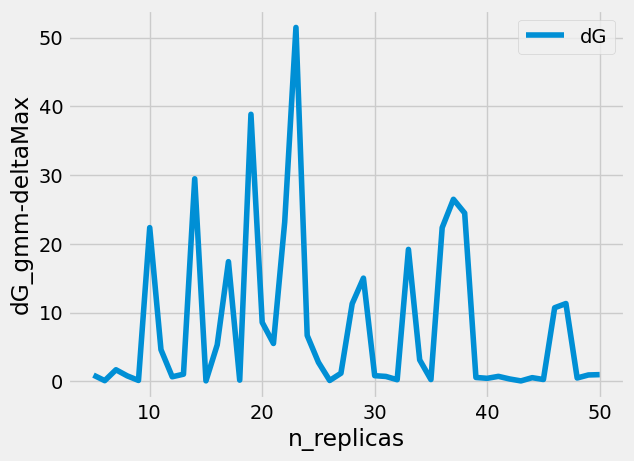

In [12]:
# sns.lineplot(data=df_conver, x='n_replicas', y='pmf_rmsd', label='Wdiss')
# sns.lineplot(data=df_conver, x='n_replicas', y='dG_gmm-rmsd', label='dG')
sns.lineplot(data=df_conver, x='n_replicas', y='dG_gmm-deltaMax', label='dG')

# sns.lineplot(data=df_conver, x='n_replicas', y='Wdiss_gmm_rmsd', label='Wdiss_gmm')

In [13]:
data = pd.read_csv(f"{sysname}/{smd_folder}/analysis/pmfs_speed_0.005.csv")
data.head()

,speed,n_replicas,quantity,r_coord,value
0,0.005,5,dG_gmm,0.981,-2.004539e-07
1,0.005,5,dG_gmm,0.982,2.018283e-03
2,0.005,5,dG_gmm,0.983,3.889186e-03
3,0.005,5,dG_gmm,0.984,1.225263e-02
4,0.005,5,dG_gmm,0.985,1.658376e-02


In [ ]:
g = sns.FacetGrid(data, col='quantity', sharey=False)
g.map(sns.lineplot, x=data['r_coord'], y=data['value'], hue=data['n_replicas'])

<Axes: xlabel='r_coord', ylabel='value'>

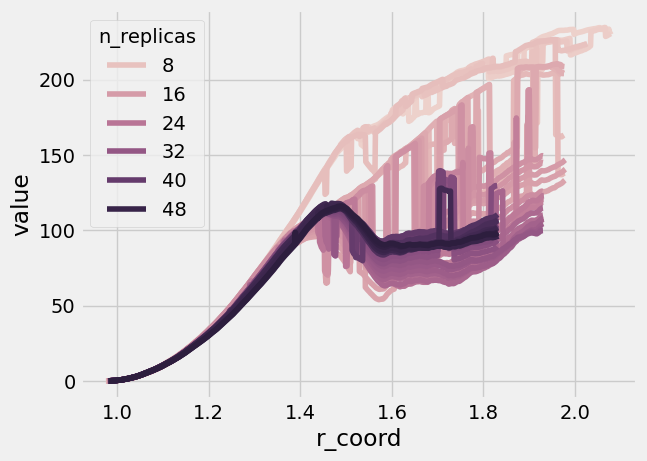

In [14]:
sns.lineplot(data=data, x='r_coord', y='value', hue='n_replicas')

### Standard dcTMD

In [ ]:
# DO THIS BY SPEED
fig, ax = plt.subplots(figsize=(12, 4), ncols=len(results['speed'].unique()), nrows=1, sharey=True, sharex=True)
axes = ax.flatten() if len(results['speed'].unique()) > 1 else [ax]

for i, speed in enumerate(sorted(results['speed'].unique())):
    speed_df = results[results['speed'] == speed].copy()
    sns.lineplot(speed_df, x='r_bin', y='Wmean', label='Wmean', ax=axes[i])
    sns.lineplot(speed_df, x='r_bin', y='dG', label='dG', ax=axes[i])
    sns.lineplot(speed_df, x='r_bin', y='Wdiss', label='Wdiss', ax=axes[i])
    axes[i].set_title(f'Speed: {speed} nm/ps', fontsize=12)
    axes[i].set_xlabel('Distance (nm)')
    axes[i].set_ylabel('dG (kJ/mol)')
    if i == 0:
        axes[i].set_ylabel('dG (kJ/mol)')
    if i != len(axes) - 1:
        axes[i].legend_.remove()

plt.xlabel('Distance (nm)'); plt.ylabel('dG (kJ/mol)')
plt.show()
plt.close()

fig, ax = plt.subplots(figsize=(12, 4), ncols=len(results['speed'].unique()), nrows=1, sharey=True, sharex=True)
axes = ax.flatten() if len(results['speed'].unique()) > 1 else [ax]

for i, speed in enumerate(sorted(results['speed'].unique())):
    speed_df = results[results['speed'] == speed].copy()
    sns.lineplot(speed_df, x='r_bin', y='Wmean_gmm', label='Wmean_gmm', ax=axes[i])
    sns.lineplot(speed_df, x='r_bin', y='dG_gmm', label='dG_gmm', ax=axes[i])
    sns.lineplot(speed_df, x='r_bin', y='Wdiss_gmm', label='Wdiss_gmm', ax=axes[i])
    axes[i].set_title(f'Speed: {speed} nm/ps', fontsize=12)
    axes[i].set_xlabel('Distance (nm)')
    axes[i].set_ylabel('dG (kJ/mol)')
    if i == 0:
        axes[i].set_ylabel('dG (kJ/mol)')
    if i != len(axes) - 1:
        axes[i].legend_.remove()

plt.xlabel('Distance (nm)'); plt.ylabel('dG (kJ/mol)')
plt.show()
plt.close()

### Jarzynski

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4), ncols=len(results['speed'].unique()), nrows=1, sharey=True, sharex=True)
axes = ax.flatten() if len(results['speed'].unique()) > 1 else [ax]

for i, speed in enumerate(sorted(results['speed'].unique())):
    speed_df = results[results['speed'] == speed].copy()
    sns.lineplot(speed_df, x='r_bin', y='Wmean', label='Wmean', ax=axes[i])
    sns.lineplot(speed_df, x='r_bin', y='dG_Jarzynski', label='dG_Jarzynski', ax=axes[i])
    sns.lineplot(speed_df, x='r_bin', y='Wdiss_Jarzynski', label='Wdiss_Jarzynski', ax=axes[i])
    axes[i].set_title(f'Speed: {speed} nm/ps', fontsize=12)
    axes[i].set_xlabel('Distance (nm)')
    axes[i].set_ylabel('kJ/mol')
    if i == 0:
        axes[i].set_ylabel('kJ/mol')
    if i != len(axes) - 1:
        axes[i].legend_.remove()

plt.xlabel('Distance (nm)'); plt.ylabel('kJ/mol')
plt.show()
plt.close()

fig, ax = plt.subplots(figsize=(12, 4), ncols=len(results['speed'].unique()), nrows=1, sharey=True, sharex=True)
axes = ax.flatten() if len(results['speed'].unique()) > 1 else [ax]

for i, speed in enumerate(sorted(results['speed'].unique())):
    speed_df = results[results['speed'] == speed].copy()
    sns.lineplot(speed_df, x='r_bin', y='Wmean_gmm', label='Wmean_gmm', ax=axes[i])
    sns.lineplot(speed_df, x='r_bin', y='dG_Jarzynski_gmm', label='dG_Jarzynski_gmm', ax=axes[i])
    sns.lineplot(speed_df, x='r_bin', y='Wdiss_Jarzynski_gmm', label='Wdiss_Jarzynski_gmm', ax=axes[i])
    axes[i].set_title(f'Speed: {speed} nm/ps', fontsize=12)
    axes[i].set_xlabel('Distance (nm)')
    axes[i].set_ylabel('kJ/mol')
    if i == 0:
        axes[i].set_ylabel('kJ/mol')
    if i != len(axes) - 1:
        axes[i].legend_.remove()

plt.xlabel('Distance (nm)'); plt.ylabel('kJ/mol')
plt.show()
plt.close()

In [ ]:
smd.plot_gmm_per_speed(gmm_results)